In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


In [3]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [4]:
bn3nc_dir = "./BN3NC"
bn3bc_dir = "./BN3BC"

bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"

bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"

bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"

bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"

Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [5]:
qs22nc, plasmon22nc, confinements22nc = [x for x in eachcol(np.loadtxt("$bn22nc_dir/Wannier/Plasmon.txt"))];
qs33nc, plasmon33nc, confinements33nc = [x for x in eachcol(np.loadtxt("$bn33nc_dir/Wannier/Plasmon.txt"))];
qs44nc, plasmon44nc, confinements44nc = [x for x in eachcol(np.loadtxt("$bn44nc_dir/Wannier/Plasmon.txt"))];

qs22bc, plasmon22bc, confinements22bc = [x for x in eachcol(np.loadtxt("$bn22bc_dir/Wannier/Plasmon.txt"))];
qs33bc, plasmon33bc, confinements33bc = [x for x in eachcol(np.loadtxt("$bn33bc_dir/Wannier/Plasmon.txt"))];
qs44bc, plasmon44bc, confinements44bc = [x for x in eachcol(np.loadtxt("$bn44bc_dir/Wannier/Plasmon.txt"))];

qs3bc, plasmon3bc, confinements3bc = [x for x in eachcol(np.loadtxt("$bn3bc_dir/Wannier/Plasmon.txt"))];
qs3nc, plasmon3nc, confinements3nc = [x for x in eachcol(np.loadtxt("$bn3nc_dir/Wannier/Plasmon.txt"))];

graphene_qs, graphene_plasmon, graphene_confinements = [x for x in eachcol(np.loadtxt("$graphene_dir/Plasmon.txt"))];

In [6]:
bn3bc_intra_qs, bn3bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn3bc_dir*"/Plasmons/plasmon.txt"))];
bn3nc_intra_qs, bn3nc_intra_plasmon = [collect(x) for x in eachcol(np.loadtxt(bn3nc_dir*"/Plasmons/plasmon.txt"))];

bn22bc_intra_qs, bn22bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn22bc_dir*"/Plasmons/plasmon.txt"))];
bn33bc_intra_qs, bn33bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn33bc_dir*"/Plasmons/plasmon.txt"))];
bn44bc_intra_qs, bn44bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn44bc_dir*"/Plasmons/plasmon.txt"))];

bn22nc_intra_qs, bn22nc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn22nc_dir*"/Plasmons/plasmon.txt"))];
bn33nc_intra_qs, bn33nc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn33nc_dir*"/Plasmons/plasmon.txt"))];
bn44nc_intra_qs, bn44nc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn44nc_dir*"/Plasmons/plasmon.txt"))];

In [17]:
# Check that the qs are consistent
for (x, y) in zip(bn3bc_intra_qs, qs3bc)
    @assert x == y
end
for (x, y) in zip(bn3nc_intra_qs, qs3nc)
    @assert x == y
end

for (x, y) in zip(bn22bc_intra_qs, qs22bc)
    @assert x == y
end
for (x, y) in zip(bn22nc_intra_qs, qs22nc)
    @assert x == y
end

for (x, y) in zip(bn33bc_intra_qs, qs33bc)
    @assert x == y
end
for (x, y) in zip(bn33nc_intra_qs, qs33nc)
    @assert x == y
end

for (x, y) in zip(bn44bc_intra_qs, qs44bc)
    @assert x == y
end
for (x, y) in zip(bn44nc_intra_qs, qs44nc)
    @assert x == y
end

In [18]:
max22bc = maximum(plasmon22bc)
max33bc = maximum(plasmon33bc)
max44bc = maximum(plasmon44bc)

max22nc = maximum(plasmon22nc)
max33nc = maximum(plasmon33nc)
max44nc = maximum(plasmon44nc)

println("BN22BC Max:",  max22bc)
println("BN33BC Max:",  max33bc)
println("BN44BC Max:",  max44bc)
println("BN22NC Max:",  max22nc)
println("BN33NC Max:",  max33nc)
println("BN44NC Max:",  max44nc)

#optional

max33bc_theoretical = 0.382;
max33nc_theoretical = 0.364;
max44bc_theoretical = 0.232;
max44nc_theoretical = 0.245;


BN22BC Max:0.8097084702400599
BN33BC Max:0.2867850231741476
BN44BC Max:0.1727303017164614
BN22NC Max:0.7383838383838384
BN33NC Max:0.3084959013661931
BN44NC Max:0.19998887648097619


In [19]:
omegas,  tau22nc_allen = [x for x in eachcol(np.loadtxt("$bn22nc_dir/Plasmons/tau_allen.txt"))];
_ , tau33nc_allen = [x for x in eachcol(np.loadtxt("$bn33nc_dir/Plasmons/tau_allen.txt"))];
_ , tau44nc_allen = [x for x in eachcol(np.loadtxt("$bn44nc_dir/Plasmons/tau_allen.txt"))];

_ , _, tau22bc_allen = [x for x in eachcol(np.loadtxt("$bn22bc_dir/Plasmons/tau_allen.txt"))];
_ , _, tau33bc_allen = [x for x in eachcol(np.loadtxt("$bn33bc_dir/Plasmons/tau_allen.txt"))];
_ , _, tau44bc_allen = [x for x in eachcol(np.loadtxt("$bn44bc_dir/Plasmons/tau_allen.txt"))];

_, _, tau_graphene_shankar, tau_graphene_allen = [x for x in eachcol(np.loadtxt("$graphene_dir/tau.txt"))];
_, _, tau_Ag_shankar, tau_Ag_allen = [x for x in eachcol(np.loadtxt("$Ag_dir/tau.txt"))];
_, _, tau_argentene_shankar, tau_argentene_allen = [x for x in eachcol(np.loadtxt("$Argentene_dir/tau.txt"))];

_ , tau3bc_allen = [x for x in eachcol(np.loadtxt("$bn3bc_dir/Plasmons/tau_allen.txt"))];
_ , tau3nc_allen = [x for x in eachcol(np.loadtxt("$bn3nc_dir/Plasmons/tau_allen.txt"))];


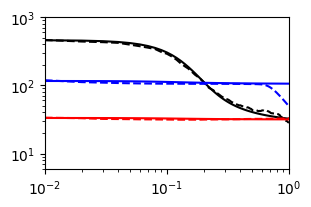

(0.01, 1)

In [20]:
#Supp Figure 4
cm = 1/2.54
figure(figsize=(8*cm, 5*cm))
omegas = collect(0.01:0.01:1)
loglog(omegas, tau_graphene_shankar, color="black")
loglog(omegas, tau_graphene_allen, linestyle="dashed", color="black")
loglog(omegas, tau_Ag_shankar, color="red")
loglog(omegas, tau_Ag_allen, linestyle="dashed", color="red")
loglog(omegas, tau_argentene_shankar, color="blue")
loglog(omegas, tau_argentene_allen, linestyle="dashed", color="blue")

ylim(6, 1000)
xlim(0.01, 1)
#savefig("Allen_v_Shankar.pdf")

In [50]:
# Figure 2

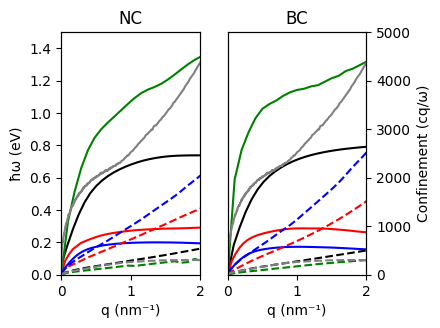

PyObject Text(0.5, 1.0, 'BC')

In [21]:
#Legend Properties
cm = 1/2.54
lab22 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black");
lab33 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red");
lab44 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="blue");
labgraphene = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="green");

figure(figsize=(10*cm, 8*cm))
subplot(1, 2, 1)
ylim(0, 1.5)
ylabel("ħω (eV)")
plot(qs22nc*10, plasmon22nc, color="black")
plot(qs33nc*10, plasmon33nc, color="red")
plot(qs44nc*10, plasmon44nc, color="blue")
plot(qs3nc*10, plasmon3nc, color="green")
plot(graphene_qs*10, graphene_plasmon, color="grey")

xlabel("q (nm⁻¹)")
xlim(0, 2)
twinx()

plot(qs22nc*10, confinements22nc, color="black", linestyle="dashed", label="22")
plot(qs33nc*10, confinements33nc, color="red", linestyle="dashed", label="33")
plot(qs44nc*10, confinements44nc, color="blue", linestyle="dashed", label="44")
plot(qs3nc*10, confinements3nc, color="green", linestyle="dashed", label="22")
plot(graphene_qs*10, graphene_confinements, color="grey", linestyle="dashed", label="labgraphene")

ylim(0, 5000)
yticks([])
#legend(handles = [lab22, lab33, lab44, labgraphene], labels = ["22", "33", "44", "Graphene"])
title("NC")

subplot(1, 2, 2)
yticks([])
ylim(0, 1.5)
plot(qs22bc*10, plasmon22bc, color="black")
plot(qs33bc*10, plasmon33bc, color="red")
plot(qs44bc*10, plasmon44bc, color="blue")
plot(qs3bc*10, plasmon3bc, color="green")
plot(graphene_qs*10, collect(graphene_plasmon), color="grey")

xlabel("q (nm⁻¹)")
xlim(0, 2)
twinx()

plot(qs22bc*10, confinements22bc, color="black", linestyle="dashed", label="22")
plot(qs33bc*10, confinements33bc, color="red", linestyle="dashed", label="33")
plot(qs44bc*10, confinements44bc, color="blue", linestyle="dashed", label="44")
plot(qs3bc*10, confinements3bc, color="green", linestyle="dashed", label="44")

plot(graphene_qs*10, graphene_confinements, color="grey", linestyle="dashed", label="graphene")

ylim(0, 5000)
ylabel("Confinement (cq/ω)")
title("BC")

#legend(handles = [lab22, lab33, lab44, labgraphene], labels = ["22", "33", "44", "Graphene"])
#savefig("AllPlasmons.pdf")

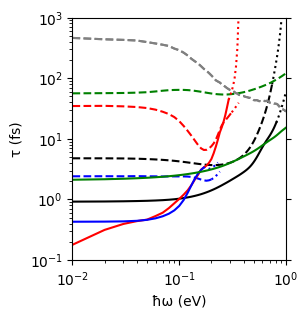

PyObject Text(0.5, 24.0, 'ħω (eV)')

In [23]:
cm = 1/2.54
lab22 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black");
lab33 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red");
lab44 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="blue");
labAg = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="green");

figure(figsize=(7*cm, 8*cm))

#optional
loglog(omegas[argmin(abs.(max22nc .- omegas)):end], tau22nc_allen[argmin(abs.(max22nc .- omegas)):end], color="black", linestyle="dotted")
loglog(omegas[argmin(abs.(max33nc .- omegas)):argmin(abs.(max33nc_theoretical .- omegas))], 
    tau33nc_allen[argmin(abs.(max33nc .- omegas)):argmin(abs.(max33nc_theoretical .- omegas))], color="red", linestyle="dotted")
loglog(omegas[argmin(abs.(max44nc .- omegas)):argmin(abs.(max44nc_theoretical .- omegas))], 
    tau44nc_allen[argmin(abs.(max44nc .- omegas)):argmin(abs.(max44nc_theoretical .- omegas))], color="blue", linestyle="dotted")

#end optional

loglog(omegas[1:argmin(abs.(max22nc .- omegas))], tau22nc_allen[1:argmin(abs.(max22nc .- omegas))], color="black", linestyle="dashed")
loglog(omegas[1:argmin(abs.(max33nc .- omegas))], tau33nc_allen[1:argmin(abs.(max33nc .- omegas))], color="red", linestyle="dashed")
loglog(omegas[1:argmin(abs.(max44nc .- omegas))], tau44nc_allen[1:argmin(abs.(max44nc .- omegas))], color="blue", linestyle="dashed")
loglog(omegas, collect(tau_graphene_allen), color="grey", linestyle="dashed")
loglog(omegas, tau3nc_allen, color="green", linestyle="dashed")

xlabel("ħω (eV)")
ylabel("τ (fs)")
#optional

#ylim(1, 1000)
xlim(0.01, 1)
ylim(0.1, 1000)
tick_params(right=true)


loglog(omegas[argmin(abs.(max22bc .- omegas)):end], tau22bc_allen[argmin(abs.(max22bc .- omegas)):end], color="black", linestyle="dotted")
loglog(omegas[argmin(abs.(max33bc .- omegas)):argmin(abs.(max33bc_theoretical .- omegas))], 
    tau33bc_allen[argmin(abs.(max33bc .- omegas)):argmin(abs.(max33bc_theoretical .- omegas))], color="red", linestyle="dotted")
loglog(omegas[argmin(abs.(max44bc .- omegas)):argmin(abs.(max44bc_theoretical .- omegas))], 
    tau44bc_allen[argmin(abs.(max44bc .- omegas)):argmin(abs.(max44bc_theoretical .- omegas))], color="blue", linestyle="dotted")

#end optional

loglog(omegas[1:argmin(abs.(max22bc .- omegas))], tau22bc_allen[1:argmin(abs.(max22bc .- omegas))], color="black", linestyle="solid")
loglog(omegas[1:argmin(abs.(max33bc .- omegas))], tau33bc_allen[1:argmin(abs.(max33bc .- omegas))], color="red", linestyle="solid")
loglog(omegas[1:argmin(abs.(max44bc .- omegas))], smooth(collect(tau44bc_allen[1:argmin(abs.(max44bc .- omegas))]), win_len=10), color="blue", linestyle="solid")
loglog(omegas, tau_graphene_allen, color="grey", linestyle="dashed")
loglog(omegas, smooth(collect(tau3bc_allen)), color="green", linestyle="solid")

xlabel("ħω (eV)")
#savefig("Alltaus_allen.pdf")

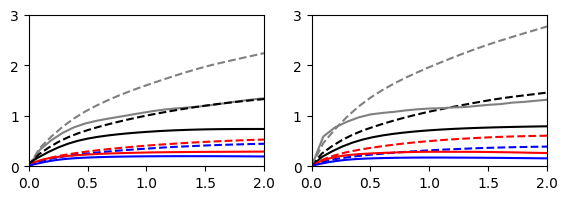

In [24]:
# Supplemental Figure 3
cm = 1/2.54
figure(figsize=(17*cm, 5*cm))
subplot(1, 2, 2)
plot(bn3bc_intra_qs*10, bn3bc_intra_plasmon, color="grey", linestyle="dashed")
plot(bn22bc_intra_qs*10, bn22bc_intra_plasmon, color="black", linestyle="dashed")
plot(bn33bc_intra_qs*10, bn33bc_intra_plasmon, color="red", linestyle="dashed")
plot(bn44bc_intra_qs*10, bn44bc_intra_plasmon, color="blue", linestyle="dashed")

plot(qs3bc*10, plasmon3bc, color="grey")
plot(qs22bc*10, plasmon22bc, color="black")
plot(qs33bc*10, plasmon33bc, color="red")
plot(qs44bc*10, plasmon44bc, color="blue")


ylim(0, 3)
xlim(0, 2)

subplot(1, 2, 1)

plot(bn3nc_intra_qs*10, bn3nc_intra_plasmon, color="grey", linestyle="dashed")
plot(qs3nc*10, plasmon3nc, color="grey")

plot(bn22nc_intra_qs*10, bn22nc_intra_plasmon, color="black", linestyle="dashed")
plot(bn33nc_intra_qs*10, bn33nc_intra_plasmon, color="red", linestyle="dashed")
plot(bn44nc_intra_qs*10, bn44nc_intra_plasmon, color="blue", linestyle="dashed")

plot(qs22nc*10, plasmon22nc, color="black")
plot(qs33nc*10, plasmon33nc, color="red")
plot(qs44nc*10, plasmon44nc, color="blue")

ylim(0, 3)
xlim(0, 2)
savefig("IntraVsInter.pdf")

In [66]:
plasmon3nc

25-element view(::Matrix{Float64}, :, 2) with eltype Float64:
 0.0
 0.3281180938041731
 0.5137443143768966
 0.6607514322731108
 0.7703833966597318
 0.847185870038126
 0.9001922675701146
 0.94183899353505
 0.9798753542784864
 1.018141671034249
 1.0566331509266167
 1.092893302400298
 1.1233697069157809
 1.1450492390320337
 1.1613403659414105
 1.1811887042660196
 1.207449748743718
 1.2377463888930416
 1.2699691139794762
 1.3011335558163155
 1.3285204159770385
 1.3507141453686866
 1.368143635872629
 1.382918398223381
 1.393987204936022

# Below we find the effective dielectric constant

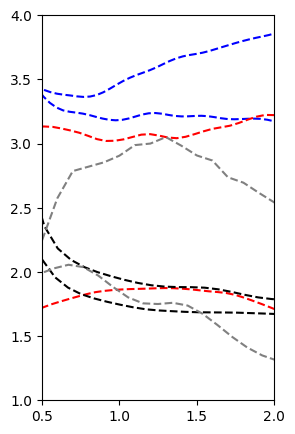

(0.5, 2.0)

In [68]:
figure(figsize=(3, 5))
x = (bn44nc_intra_plasmon ./ plasmon44nc[1:50]).^2 .- 1;
plot(qs44nc[2:50]*10, smooth(x[2:50] ./ (bohrtoangstrom*12.69*qs44nc[2:50]), win_len=3), linestyle="dashed"
, color="blue")

x = (bn44bc_intra_plasmon ./ plasmon44bc[1:50]).^2 .- 1;
plot(qs44bc[2:50]*10, smooth(x[2:50] ./ (bohrtoangstrom*12.69*qs44bc[2:50]), win_len=2), linestyle="dashed",
color="blue")

x = (bn33nc_intra_plasmon ./ plasmon33nc[1:50]).^2 .- 1;
plot(qs33nc[2:50]*10, smooth(x[2:50] ./ (bohrtoangstrom*12.69*qs33nc[2:50]), win_len=3), linestyle="dashed", 
color="red")

x = (bn33bc_intra_plasmon ./ plasmon33bc[1:50]).^2 .- 1;
plot(qs33bc[2:50]*10, smooth(x[2:50] ./ (bohrtoangstrom*12.69*qs33bc[2:50]), win_len=3), linestyle="dashed", 
color="red")

x = (bn22bc_intra_plasmon ./ plasmon22bc[1:50]).^2 .- 1;
plot(qs22bc[2:50]*10, smooth(x[2:50] ./ (bohrtoangstrom*12.69*qs22bc[2:50]), win_len=3), linestyle="dashed", 
color="black")

x = (bn22nc_intra_plasmon ./ plasmon22nc[1:50]).^2 .- 1;
plot(qs22nc[2:50]*10, smooth(x[2:50] ./ (bohrtoangstrom*12.69*qs22nc[2:50]), win_len=3), linestyle="dashed", 
color="black")

x = (bn3nc_intra_plasmon[1:25] ./ plasmon3nc[1:25]).^2 .- 1;
plot(qs3nc[2:25]*10, smooth(x[2:25] ./ (bohrtoangstrom*12.69*qs3nc[2:25]), win_len=3), linestyle="dashed", 
color="grey")

x = (bn3bc_intra_plasmon[1:25] ./ plasmon3bc[1:25]).^2 .- 1;
plot(qs3bc[2:25]*10, smooth(x[2:25] ./ (bohrtoangstrom*12.69*qs3bc[2:25]), win_len=3), linestyle="dashed", 
color="grey")


ylim(1, 4)
xlim(0.5, 2)